# In this Notebook:
>## Fine-Tunning MobileNetV2 on 2-Phases for Face-Emotion Recognition

## Version notes:
- disbale softmax, and use "from_logits=True" in the loss function
- changed batch size from 128 to 256
- decrease the number of unfrozen layers from 38 to 20

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense,Input,Dropout,GlobalAveragePooling2D,Flatten,Conv2D,BatchNormalization,Activation,MaxPooling2D
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.optimizers import Adam,SGD,RMSprop


2026-05-21 17:13:50.613700: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779383630.836441      40 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779383630.906148      40 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
print(tf.__version__)

2.18.0


In [4]:
print(os.listdir('../input/face-expression-recognition-dataset/images/'))

['validation', 'images', 'train']


# 1. Working with Data

## 1.1 Calculating the Count of images in each class

### 1.1.1 Old Dataset
>/kaggle/input/datasets/jonathan-oheix/face-expression-recognition-dataset

In [5]:
folder_path = '../input/face-expression-recognition-dataset/images/'
total_images_count = 0

print("Number of images per expression (class):")
tabel_header = f"{'Category':10} = {'Train':>7}, {'Validation':>7}"
print(len(tabel_header)*'-')
print(tabel_header)
print(len(tabel_header)*'-')
expressions = os.listdir(folder_path + "train/")
for expression in expressions:
    print(f"{expression:10} = ", end='')
    expression_train_images_count = len(os.listdir(os.path.join(folder_path, 'train' ,expression)))
    expression_val_images_count = len(os.listdir(os.path.join(folder_path, 'validation' ,expression)))
    print(f"{expression_train_images_count:7}, {expression_val_images_count:7}")
    total_images_count += expression_train_images_count + expression_val_images_count
print("Total Images count = ", total_images_count)

Number of images per expression (class):
--------------------------------
Category   =   Train, Validation
--------------------------------
surprise   =    3205,     797
fear       =    4103,    1018
angry      =    3993,     960
neutral    =    4982,    1216
sad        =    4938,    1139
disgust    =     436,     111
happy      =    7164,    1825
Total Images count =  35887


### 1.1.2 New Dataset
> /kaggle/input/datasets/fahadullaha/facial-emotion-recognition-dataset

In [5]:
folder_path = "/kaggle/input/datasets/fahadullaha/facial-emotion-recognition-dataset/processed_data"
total_images_count = 0

print("Number of images per expression (class):")
expressions = os.listdir(folder_path)
for expression in expressions:
    print(f"{expression:10} = ", end='')
    expression_images_count = len(os.listdir(os.path.join(folder_path, expression)))
    print(f"{expression_images_count:7}")
    total_images_count += expression_images_count
print('Total Images count = ', total_images_count)

Number of images per expression (class):
surprise   =    5920
fear       =    5920
angry      =    5920
neutral    =    8166
sad        =    6535
disgust    =    5920
happy      =   11398
Total Images count =  49779


## 1.2 Sample Visualization

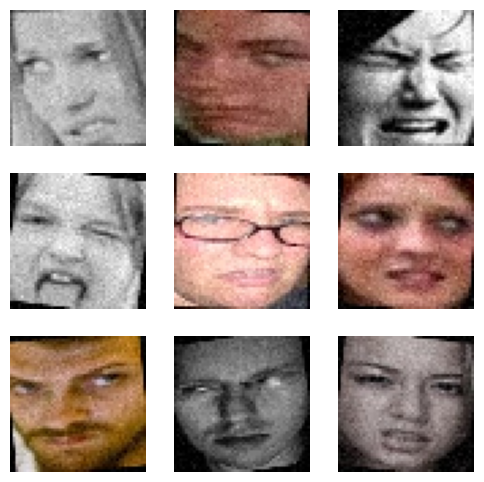

In [9]:
expression = 'disgust'
experssion_dir_path = os.path.join(folder_path, expression)
picture_size = 50

plt.figure(figsize= (6,6))
for i in range(1, 10, 1):
    plt.subplot(3,3,i)
    img = load_img(os.path.join(experssion_dir_path, os.listdir(experssion_dir_path)[i+100]),
                   target_size=(picture_size, picture_size))
    plt.imshow(img)
    plt.axis('off')
plt.show()

## 1.3 Data Preparation

In [6]:
!pip install split-folders

### Splitting the data into train, test and val directories

In [7]:
import splitfolders

input_folder = folder_path 

# The path to the new structured dataset folders
output_folder = "/kaggle/working/structured_dataset"

# This splits it into 70% Train, 15% Validation, 15% Test
splitfolders.ratio(input_folder, 
                   output=output_folder, 
                   seed=42, 
                   ratio=(0.7, 0.15, 0.15), 
                   group_prefix=None)

Copying files: 49779 files [07:44, 107.20 files/s]


In [8]:
!df -h /kaggle/working

Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  269M   20G   2% /kaggle/working


In [9]:
folder_path = output_folder

In [10]:
print("Number of images per expression (class):")
tabel_header = f"{'Category':10} = {'Train':>7}, {'Validation':>7}, {'Test':>7}"
print(len(tabel_header)*'-')
print(tabel_header)
print(len(tabel_header)*'-')
expressions = os.listdir(folder_path + "/train/")
for expression in expressions:
    print(f"{expression:10} = ", end='')
    print(f"{len(os.listdir(folder_path + '/train/' + expression)):7}, {len(os.listdir(folder_path + '/val/' + expression)):7}, {len(os.listdir(folder_path + '/test/' + expression)):7}")

Number of images per expression (class):
-----------------------------------------
Category   =   Train, Validation,    Test
-----------------------------------------
surprise   =    4144,     888,     888
fear       =    4144,     888,     888
angry      =    4144,     888,     888
disgust    =    4144,     888,     888
sad        =    4574,     980,     981
neutral    =    5716,    1224,    1226
happy      =    7978,    1709,    1711


## 1.4 Data Loading
### Using `image_dataset_from_directory` which is a more CPU-GPU efficient method

In [11]:
batch_size  = 64
picture_size = 224

# Training set (with validation split)
train_ds = tf.keras.utils.image_dataset_from_directory(
    folder_path+"/train",
    # validation_split=0.2,
    # subset="training",
    seed=1,
    image_size=(picture_size, picture_size),
    batch_size=batch_size,
    color_mode="rgb",       # grayscale->3 channel done here
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    folder_path+"/val",
    # validation_split=0.2,
    # subset="validation",
    seed=1,
    image_size=(picture_size, picture_size),
    batch_size=batch_size,
    color_mode="rgb",
    label_mode="categorical"
)

# Test set
test_ds = tf.keras.utils.image_dataset_from_directory(
    folder_path+"/test",
    image_size=(picture_size, picture_size),
    batch_size=batch_size,
    color_mode="rgb",
    label_mode="categorical",
    shuffle=False
)
class_names = list(train_ds.class_names)  # can't get class names after calling "prefetch"

Found 34844 files belonging to 7 classes.


I0000 00:00:1779384161.689433      40 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 7465 files belonging to 7 classes.
Found 7470 files belonging to 7 classes.


## 1.5 Using AutoTune & Prefetch
### - For mitigating the problem of having GPU `idle` waiting for CPU to load the next batch

In [12]:
# TensorFlow automatically decide the best value for things like buffering and parallelism based on the current system (CPU, GPU, RAM) 
AUTOTUNE = tf.data.AUTOTUNE

# prefetch: Loads the next batch of data while the model is training on the current batch.
# Load data using CPU, at the same time train the model with the GPU, to prevent CPU bottleneck between each batch, and also prevents memory bottleneck when loading images from disk

train_ds = train_ds.shuffle(250).prefetch(buffer_size=AUTOTUNE)   # shuffle(1000)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)

print('Done')

Done


# 2. Working with Augmentation

## 2.1 Visualization function for Augmentation effect 

In [13]:
def augmentation_visual(aug_layer):
    import random
    
    images_path = os.path.join(folder_path, "train")
    expressions = os.listdir(images_path)
    selected_images_paths = []
    for exp in expressions:
        images_file_names = os.listdir(os.path.join(images_path, exp))[:6]  # load a sample of 6 images from each class
        for image_file_name in images_file_names:
            selected_images_paths.append(os.path.join(images_path, exp, image_file_name))
    
    random.shuffle(selected_images_paths)
    sample_paths = selected_images_paths[:2]

    rescale_layer = layers.Rescaling(1./255, name="rescale")
    plt.figure(figsize=(8, 6))
    for i, img_path in enumerate(sample_paths):
        image = tf.keras.utils.load_img(img_path, target_size=(224, 224))
        image_array = tf.keras.utils.img_to_array(image)

        # Adding batch dim
        image_batch = tf.expand_dims(image_array, axis=0)
    
        rescaled_image = rescale_layer(image_batch, training=True)
        augmented_image = aug_layer(rescaled_image, training=True)
    
        # Plotting original
        ax = plt.subplot(2, 2, 2*i + 1)
        plt.imshow(image_array.astype("uint8"))
        plt.title("Original")
        plt.axis("off")
    
        # Plotting augmented
        ax = plt.subplot(2, 2, 2*i + 2)
        plt.imshow(augmented_image[0])
        plt.title("Augmented")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

## 2.2 Creating a custom salt and paper augmentation layer

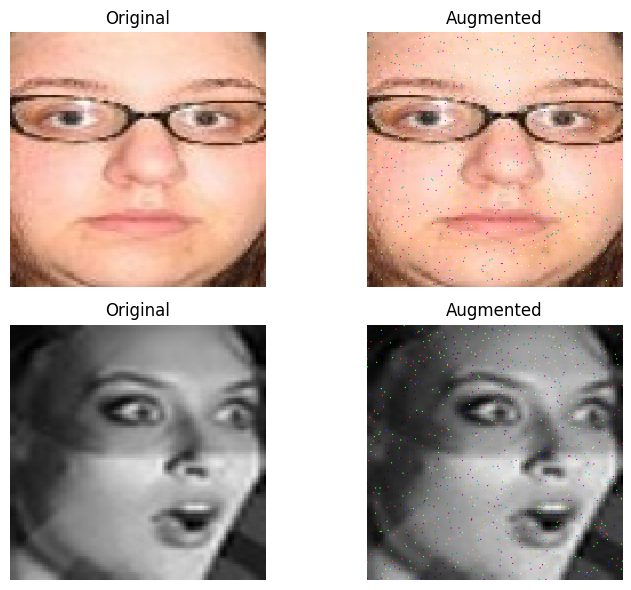

In [14]:
class SaltAndPepperNoise(layers.Layer):
    def __init__(self, amount=0.05, salt_vs_pepper=0.5, **kwargs):
        super().__init__(**kwargs)
        self.amount = amount  # proportion of pixels to alter
        self.salt_vs_pepper = salt_vs_pepper  # ratio of salt vs pepper

    def call(self, inputs, training=None):
        if not training:
            return inputs

        # Generating random mask
        random_tensor = tf.random.uniform(tf.shape(inputs), 0, 1)

        # Salt mask (set to 1)
        salt_mask = random_tensor < (self.amount * self.salt_vs_pepper)

        # Pepper mask (set to 0)
        pepper_mask = (random_tensor >= (self.amount * self.salt_vs_pepper)) & \
                      (random_tensor < self.amount)

        # Appling noise
        outputs = tf.where(salt_mask, tf.ones_like(inputs), inputs)
        outputs = tf.where(pepper_mask, tf.zeros_like(inputs), outputs)

        return outputs

    def get_config(self):
        config = super().get_config()
        config.update({
            "amount": self.amount,
            "salt_vs_pepper": self.salt_vs_pepper
        })
        return config

salt_and_paper_filter = SaltAndPepperNoise(amount=0.01) # 0.05
augmentation_visual(salt_and_paper_filter)


## 2.3 Augmentation block definition

### 2.3.1 Augmentation Settings for Logging

In [15]:
augmentation_params = {
    "aug_rotation_range": 10,
    "aug_translation": 0.1,
    "aug_zoom_range": 0.1,
    "aug_contrast_range": 0.1,
    "aug_horizontal_flip": True,
    # "aug_salt_paper": 0.01
}

### 2.3.2 Defining the Tensorflow Augmentation layer

In [16]:
data_augmentation = Sequential([
    layers.RandomRotation(augmentation_params["aug_rotation_range"]/360),
    layers.RandomTranslation(augmentation_params["aug_translation"], augmentation_params["aug_translation"]),
    layers.RandomZoom(augmentation_params["aug_zoom_range"]),
    layers.RandomContrast(augmentation_params["aug_contrast_range"]),
    layers.RandomFlip("horizontal"),
], name="augmentation")


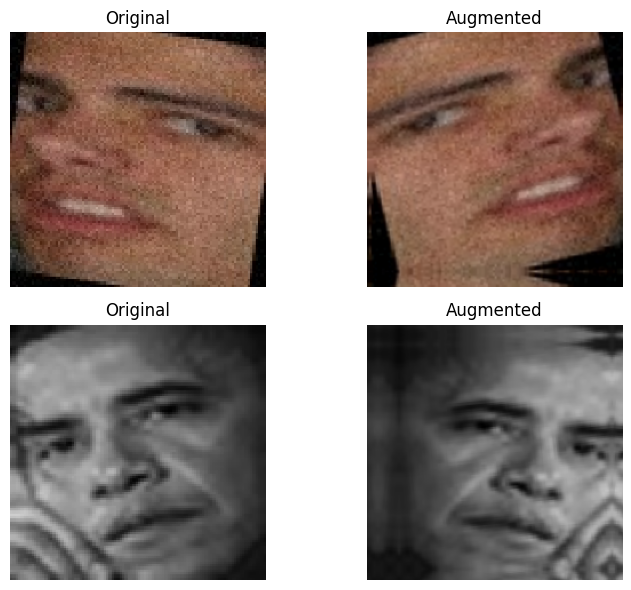

In [17]:
augmentation_visual(data_augmentation)

# 3. Final Model

## 3.1 Model **Phase-1**

### 3.1.1 Defining the HyperParameters for logging

In [18]:
custom_head_config = {
    "num_dense_layers": 2,
    "layer_1_units": 512,
    "layer_1_dropout_rate": 0.3,
    "layer_2_units": 256,
    "layer_2_dropout_rate": 0.3,
}

### 3.1.2 `Phase-1` Model Definition, Fine-Tunning `MobileNetV2`

In [19]:
from tensorflow.keras import layers, Model, Sequential

# Rescaling (always applied, train + val + test)
rescale = layers.Rescaling(1./255, name="rescale")

# salt_and_paper_filter = SaltAndPepperNoise(amount=augmentation_params["aug_salt_paper"])

# Loading MobileNetV2 backbone (no top)
base_model = tf.keras.applications.MobileNetV2(
    weights=None,
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.load_weights("../input/mobilenet-v2-no-top/mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top.h5")
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))    # critical bug: shape=(224, 224, 1) 
x = rescale(inputs)                          
x = data_augmentation(x)    # critical bug: setting "training=True" , it forces applying augmentation to be  to val and test data
# x = salt_and_paper_filter(x)
x = base_model(x, training=False)            # Feeding to MobileNetV2
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(custom_head_config["layer_1_units"], activation="relu")(x) # first additional layer other than single softmax layer
x = layers.BatchNormalization()(x)          
x = layers.Dropout(custom_head_config["layer_1_dropout_rate"])(x) #0.3
x = layers.Dense(custom_head_config["layer_2_units"], activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(custom_head_config["layer_2_dropout_rate"])(x)   #0.2     # stronger dropout to prevent overfitting than the (0.3), which was used with the single output layer
outputs = layers.Dense(7, activation="linear")(x)

model = Model(inputs, outputs, name="mobilenetv2_finetune_phase1")
model.summary()

Model: "mobilenetv2_finetune_phase1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale (Rescaling)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,050,055 (11.64 MB)

 Trainable params: 790,535 (3.02 MB)

 Non-trainable params: 2,259,520 (8.62 MB)

### 3.1.3 Defining `Phase-1` Training Callbacks

In [20]:
from keras.optimizers import RMSprop,SGD,Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.losses import CategoricalCrossentropy
checkpoint = ModelCheckpoint("/kaggle/working/model_phase1.h5", monitor='val_loss', verbose=1, save_best_only=True, mode='min')
early_stopping = EarlyStopping(monitor='val_loss',min_delta=0, patience=6, verbose=1, restore_best_weights=True)
reduce_learningrate = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1, min_delta=0.0001, min_lr=0.000005)
callback_list = [early_stopping,checkpoint,reduce_learningrate]
epochs_count = 15

model.compile(loss=CategoricalCrossentropy(from_logits=True),
              optimizer = Adam(learning_rate=1e-3),
              metrics=['accuracy'])

### 3.1.4 Phase-1 Training
>#### Freezing the whole model and only Training the New `Classification Head`

In [21]:
history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=epochs_count,
                    callbacks=callback_list)

Epoch 1/15


I0000 00:00:1779384227.486747     131 cuda_dnn.cc:529] Loaded cuDNN version 90300


545/545 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.3970 - loss: 1.7676
Epoch 1: val_loss improved from inf to 1.30226, saving model to /kaggle/working/model_phase1.h5
545/545 ━━━━━━━━━━━━━━━━━━━━ 75s 92ms/step - accuracy: 0.3971 - loss: 1.7673 - val_accuracy: 0.5098 - val_loss: 1.3023 - learning_rate: 0.0010
Epoch 2/15
545/545 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.4860 - loss: 1.3518
Epoch 2: val_loss improved from 1.30226 to 1.25732, saving model to /kaggle/working/model_phase1.h5
545/545 ━━━━━━━━━━━━━━━━━━━━ 53s 87ms/step - accuracy: 0.4860 - loss: 1.3518 - val_accuracy: 0.5218 - val_loss: 1.2573 - learning_rate: 0.0010
Epoch 3/15
545/545 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.5147 - loss: 1.2821
Epoch 3: val_loss improved from 1.25732 to 1.22160, saving model to /kaggle/working/model_phase1.h5
545/545 ━━━━━━━━━━━━━━━━━━━━ 53s 87ms/step - accuracy: 0.5147 - loss: 1.2821 - val_accuracy: 0.5358 - val_loss: 1.2216 - learning_rate: 0.0010
Epoch 4/15
545/545 ━━━━━━

## 3.2 Model **Phase-2**

### 3.2.1 Defining the HyperParameters for logging

In [22]:
hyper_params = {
    "phase2_optimizer": 'Adam',
    "phase2_lr": 1e-5,
    "unfrozen_layers": 20,
    "phase2_epochs": 50,
    "batch_size": batch_size
}

### 3.2.2 Loading `Phase-1` model with its best weights, and Unfreezing N-layers for Fine-Tunning

In [23]:
# 1. Loading the best weights from Phase 1
# This ensures starting Phase 2 from the best checkpoint
model.load_weights("/kaggle/working/model_phase1.h5")

# 2. Unfreezing the base model
base_model.trainable = True

# 3. Freezing the early layers, and leaving late layers unfreezed
print("Number of layers in the base model: ", len(base_model.layers))

# Freezing from layer 1 till (total_layers - unfrozen_layers_count)
# Example: 37 trainable layers, then Freezing layer 1 to 117 (leaving the last 37 layers)
fine_tune_at = len(base_model.layers) - hyper_params["unfrozen_layers"]

# Freezing everything before 'fine_tune_at'
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# printing how many layers are now trainable
trainable_count = sum([1 for w in model.trainable_weights])
print(f"Number of trainable weight tensors: {trainable_count}")

Number of layers in the base model:  154
Number of trainable weight tensors: 31


First, i was saving the model with the "highest" validation accuracy, using ModelCheckpoint and setting monitor='val_accuracy' but that turned to be not the best practice, we should save (to be used in production) the model with the "least" validation loss as (it is not gaurenteed that the epoch that has the highest val acc, also has the least val loss),

the val loss is more representitive to the model's actual performance, because if the model predicts the output as 51% Class A or 99% Class A, and the true label is actually class A, then both the outputs has the same effect on the accuracy, but the loss confident score should be penalized even correctly predicted the output, while the correct high confidence should get tiny penalty. on the other hand if the model predicts the output as Class A with probability 51%(0.51) or 99%, but the actual true label is Class B, then also the Accuracy metric treats both of them the same, but the validation loss gives high penalty for the worngly overconfident prediction, while less penalty for the low-confident worng prediction, so even if bith of them are wrong predictions, but they have different effect on the loss (as both of them getts different penalty) unlike the Accuracy Metric.

### 3.2.3 Defining Phase-2 Training Callbacks

In [24]:
# 4. Updating Callbacks for Phase 2
# changeing (monitor= "val_accuracy") at ModelCheckpoint to ('val_loss')
checkpoint_phase2 = ModelCheckpoint("/kaggle/working/model_phase2.h5", monitor='val_loss', verbose=1, save_best_only=True, mode='min')
early_stopping_phase2 = EarlyStopping(monitor='val_loss', min_delta=0, patience=5, verbose=1, restore_best_weights=True) 
reduce_lr_phase2 = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1, min_lr=1e-7)

callbacks_phase2 = [checkpoint_phase2, early_stopping_phase2, reduce_lr_phase2]

# 5. Recompiling the model
# using a high learning rate here, will destroy the pre-trained weights, so we use a smaller learning rate
model.compile(loss=CategoricalCrossentropy(from_logits=True),
              optimizer=Adam(learning_rate=hyper_params["phase2_lr"]),
              metrics=['accuracy'])

### 3.2.4 Phase-2 Training

In [25]:
# 6. Model Training
epochs_phase2 = hyper_params["phase2_epochs"]

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs_phase2,
    callbacks=callbacks_phase2
)

Epoch 1/50
545/545 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.4493 - loss: 1.4911
Epoch 1: val_loss improved from inf to 1.55405, saving model to /kaggle/working/model_phase2.h5
545/545 ━━━━━━━━━━━━━━━━━━━━ 76s 105ms/step - accuracy: 0.4494 - loss: 1.4910 - val_accuracy: 0.5078 - val_loss: 1.5541 - learning_rate: 1.0000e-05
Epoch 2/50
545/545 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.5241 - loss: 1.2725
Epoch 2: val_loss improved from 1.55405 to 1.24293, saving model to /kaggle/working/model_phase2.h5
545/545 ━━━━━━━━━━━━━━━━━━━━ 60s 101ms/step - accuracy: 0.5241 - loss: 1.2724 - val_accuracy: 0.5499 - val_loss: 1.2429 - learning_rate: 1.0000e-05
Epoch 3/50
545/545 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.5432 - loss: 1.1960
Epoch 3: val_loss improved from 1.24293 to 1.15764, saving model to /kaggle/working/model_phase2.h5
545/545 ━━━━━━━━━━━━━━━━━━━━ 61s 102ms/step - accuracy: 0.5432 - loss: 1.1960 - val_accuracy: 0.5603 - val_loss: 1.1576 - learning_rate: 1.0000e-05

# 4. Verifing Results

In [36]:
best_loss_epoch = np.argmin(history_phase2.history['val_loss']) # starting from 0 (zero-indexed)

best_val_loss = history_phase2.history['val_loss'][best_loss_epoch]
val_acc_at_best_loss = history_phase2.history['val_accuracy'][best_loss_epoch]
train_acc_at_best_loss = history_phase2.history['accuracy'][best_loss_epoch]

best_acc_epoch = np.argmax(history_phase2.history['val_accuracy'])

best_val_acc = history_phase2.history['val_accuracy'][best_acc_epoch]
val_loss_at_best_acc = history_phase2.history['val_loss'][best_acc_epoch]


>## Its not guarented that the epoch with the best validation accuracy matches that with the best validation loss.

In [27]:
print("Epoch index of best Validation Accuracy: ", best_acc_epoch)
print("Best Validation Accuracy: ", best_val_acc)
print("-"*70)
print("Epoch index of best (Least) Validation Loss: ", best_loss_epoch)
print("Best Validation Loss: ", best_val_loss)

Epoch index of best Validation Accuracy:  46
Best Validation Accuracy:  0.649832546710968
----------------------------------------------------------------------
Epoch index of best (Least) Validation Loss:  46
Best Validation Loss:  0.9472964406013489


# 5. Visualizations

## 5.1 Confusion Matrix

<class 'numpy.ndarray'>


Text(0.5, 1.0, 'Validation Confusion Matrix')

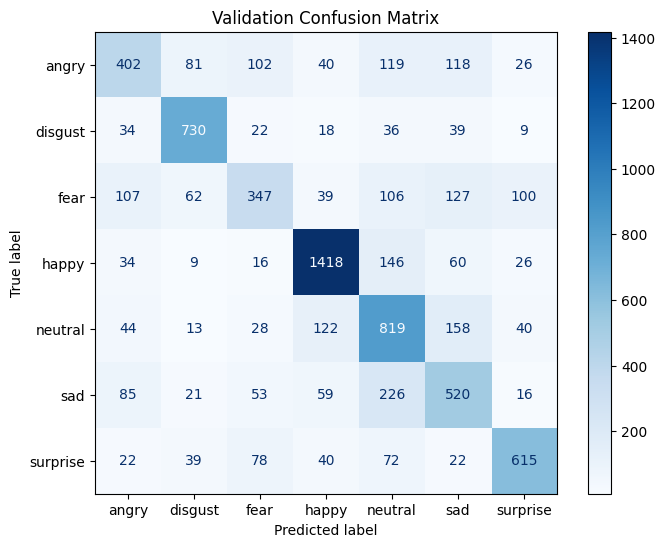

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_labels = []
all_preds = []
for images, labels in val_ds:
    all_labels.extend(np.argmax(labels.numpy(), axis=1))
    all_preds.extend(np.argmax(model.predict(images, verbose=0), axis=1))


cm = confusion_matrix(all_labels, all_preds)
print(type(cm))

# Plot it
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Validation Confusion Matrix')

# mlflow.log_figure(fig, "evaluation_plots/confusion_matrix.png")
# mlflow.log_dict(cm.tolist(), "evaluation/confusion_matrix_raw.json")

## 5.2 Training Logs

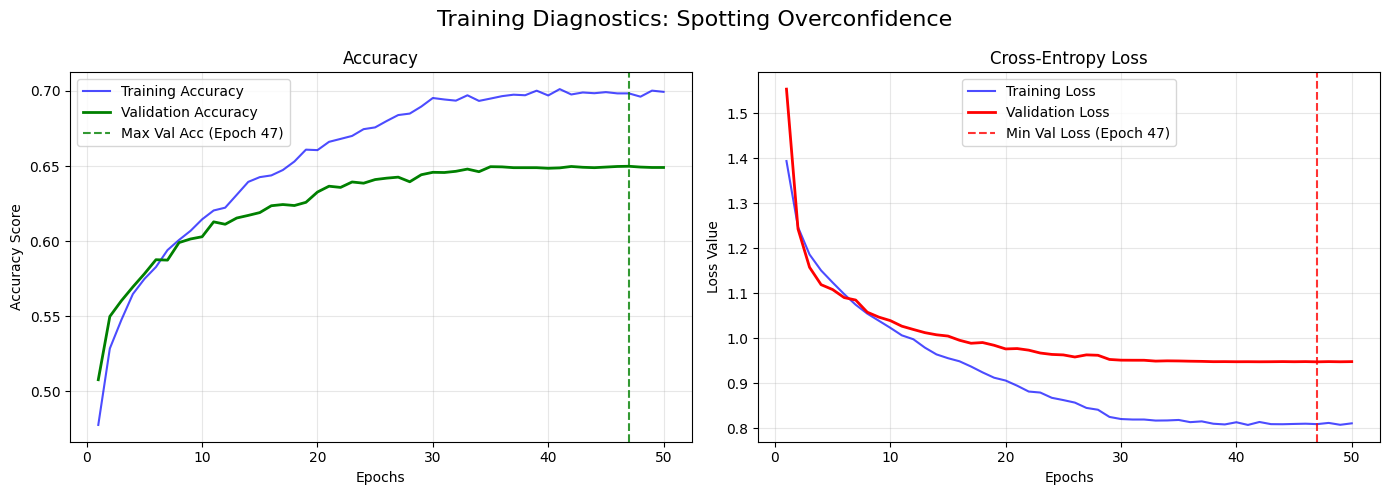

In [29]:
def plot_training_curves(history):
    
    # Extracting metrics (handles both 'acc' and 'accuracy' naming conventions)
    acc = history.history.get('accuracy', history.history.get('acc'))
    val_acc = history.history.get('val_accuracy', history.history.get('val_acc'))
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    epochs = range(1, len(acc) + 1)
    
    # finding the critical epochs
    best_loss_epoch = np.argmin(val_loss) + 1
    best_acc_epoch = np.argmax(val_acc) + 1
    
    # creating a side-by-side figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Training Diagnostics: Spotting Overconfidence', fontsize=16)
    
    # Plot 1: Accuracy, (Train Acc & Val Acc)
    ax1.plot(epochs, acc, 'b-', alpha=0.7, label='Training Accuracy')
    ax1.plot(epochs, val_acc, 'g-', linewidth=2, label='Validation Accuracy')
    ax1.axvline(x=best_acc_epoch, color='g', linestyle='--', alpha=0.8, label=f'Max Val Acc (Epoch {best_acc_epoch})')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy Score')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Loss (Train loss & Val loss)
    ax2.plot(epochs, loss, 'b-', alpha=0.7, label='Training Loss')
    ax2.plot(epochs, val_loss, 'r-', linewidth=2, label='Validation Loss')
    ax2.axvline(x=best_loss_epoch, color='r', linestyle='--', alpha=0.8, label=f'Min Val Loss (Epoch {best_loss_epoch})')
    ax2.set_title('Cross-Entropy Loss')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss Value')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    return fig

diagnostic_fig = plot_training_curves(history_phase2)

# 6. Defining Metric results and Dataset info for Logging

In [30]:
dataset_info = {
    "dataset_name": "Facial Emotion Recognition Dataset",
    "dataset_link": "https://www.kaggle.com/datasets/fahadullaha/facial-emotion-recognition-dataset",
    "dataset_description": "FER2013 and RAFDB datasets, It has more images in the disgust class, and overall more images (49k), but still imabalnced"
}

metrics_log = {
    "best_val_loss": best_val_loss,
    "val_acc_at_best_loss": val_acc_at_best_loss,
    "best_loss_epoch": int(best_loss_epoch+1),

    "best_val_acc": best_val_acc,
    "val_loss_at_best_acc": val_loss_at_best_acc,
    "best_acc_epoch": int(best_acc_epoch+1)
}

# 7. Using **MLFlow** and **DagsHub**

## 7.1 Installing DagsHub library

In [31]:
!pip install mlflow==2.9.2 dagshub==0.3.8 --quiet

# this may solve some comptability issues:
# !pip uninstall -y protobuf 
# !pip install mlflow==2.9.2 dagshub==0.3.8 protobuf==3.20.3 pydantic==1.10.13 --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 45.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.5/185.5 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.1/148.1 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.0/38.0 MB 34.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.5/506.5 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 15.5 

## 7.2 Defining the Experiment

In [32]:
import mlflow
import dagshub

dagshub.init(repo_owner='michael-nabil', repo_name='face-emotion-recognition', mlflow=True)

# setting experiment name
mlflow.set_experiment("face_emotion_recognition")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=53abfda0-8488-41a8-8d1d-9ff5915b0821&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=21dbc9d0b6f89cf8ba66aa71b45f4c09be558ad9f0b4addb174ff43a8364db02




Repository initialized!

<Experiment: artifact_location='mlflow-artifacts:/bc671168ecb54f61b322b2fe9db31761', creation_time=1773706386192, experiment_id='0', last_update_time=1773706386192, lifecycle_stage='active', name='face_emotion_recognition', tags={'mlflow.experimentKind': 'custom_model_development'}>

# 7.3 Logging Artifacts, Metrics, Hparams 

In [38]:
# starting MLflow run
with mlflow.start_run(run_name="Exp7_second_dataset_and_smaller_batch"):
    
    mlflow.log_params(hyper_params)
    mlflow.log_params(custom_head_config)

    mlflow.log_params(augmentation_params)
    mlflow.log_params(dataset_info)
    
    # mlflow.log_metric("val_accuracy", val_accuracy)
    mlflow.log_metric("train_accuracy", train_acc_at_best_loss)
    mlflow.log_metrics(metrics_log)

    
    # 3. Evaluating on the Test Set & Log Test Metrics (should be used with final model)
    # test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    # mlflow.log_metric("test_accuracy", test_acc)

    # 4. Logging (The Validation set Confusion Matrix) + (Accuracy & Loss Diagnostics plot)

    mlflow.log_figure(diagnostic_fig, "evaluation_plots/training_curves.png")
    mlflow.log_figure(fig, "evaluation_plots/confusion_matrix.png")
    mlflow.log_dict(cm.tolist(), "evaluation/confusion_matrix_raw.json")  # log the confusion matrix as a json file
    
    mlflow.log_artifact("/kaggle/working/model_phase2.h5", artifact_path="saved_models")

    mlflow.set_tag("experiment_type", "changing_dataset")
    mlflow.set_tag(
        "mlflow.note.content", 
        "using a dataset with more images and more balanced classes, but still has imbalances"
    )
    
    # mlflow.set_tag("experiment_type", "bug_fix")
    # mlflow.set_tag(
    #     "mlflow.note.content", 
    #     "Fixed the augmentation data leak. Applying data augmentation to training set only."
    # )

- experiment_types: (hparam_tuning, architecture_change, bug_fix)

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")

# Model improvements ideas

### 1- use SGD with momentum=0.9
### 2- add a Layer or two layers in the FC classification head
### 3- change batch size
### 4- change learning rate
### 5- change in the augmentations
### 6- decreaset he number of unfreezed layers

## --------------------------------------------------------------------

## 1- change N of frozen layers, using SGD in pahse 2
## 2- add a layer in the classification head + change N of frozen layers + use SGD in phase2
## 3- Add penalty on the cost of underrepresented classes (disguast)
## 4- for each image in disuguast class, create 4 augmented versions for it during training